#  Brain Tumor Detection — CNN + VGG16

---
##  How to Get the Dataset — 3 Simple Steps

**Step 1:** Go to this link  https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

**Step 2:** Click the **Download** button (top right). It downloads a ZIP file to your PC.

**Step 3:** Come back here and run **Step 1** below — it will ask you to upload that ZIP file.

> That's it! No API key, no JSON file, no complicated setup.

##  Step 0: Install & Import Libraries

In [1]:
!pip install opencv-python-headless --quiet

import os, shutil, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print(' All libraries ready!')

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 All libraries ready!


---
##  Step 1: Upload the Dataset ZIP

In [2]:
# ── Upload the ZIP file you downloaded from Kaggle ──
from google.colab import files

print(' A file picker will appear below.')
print('   Select the ZIP file you downloaded from Kaggle.')
print('   (It is usually named: brain-mri-images-for-brain-tumor-detection.zip)')
print()

uploaded = files.upload()   # ← File picker appears here

# Get the uploaded filename
zip_filename = list(uploaded.keys())[0]
print(f'\n Uploaded file: {zip_filename}')

 A file picker will appear below.
   Select the ZIP file you downloaded from Kaggle.
   (It is usually named: brain-mri-images-for-brain-tumor-detection.zip)



Saving archive.zip to archive (1).zip

Uploaded file: archive (1).zip


##  Step 2: Extract & Find the Dataset Folders

In [11]:
# ---- Extract Dataset and Validate Folders ----
import zipfile, os

# Extract ZIP
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('/content/brain_data')

# Find yes/ and no/ folders
YES_DIR, NO_DIR = None, None
for root, dirs, _ in os.walk('/content/brain_data'):
    for d in dirs:
        if d.lower() == 'yes':
            YES_DIR = os.path.join(root, d)
        if d.lower() == 'no':
            NO_DIR = os.path.join(root, d)

# Count images
yes_imgs = [f for f in os.listdir(YES_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
no_imgs  = [f for f in os.listdir(NO_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]

# Show dataset summary
print("Tumor images:", len(yes_imgs))
print("No Tumor images:", len(no_imgs))
print("Total images:", len(yes_imgs) + len(no_imgs))

Tumor images: 155
No Tumor images: 98
Total images: 253


---
## 👁️ Step 3: Visualize Sample Images

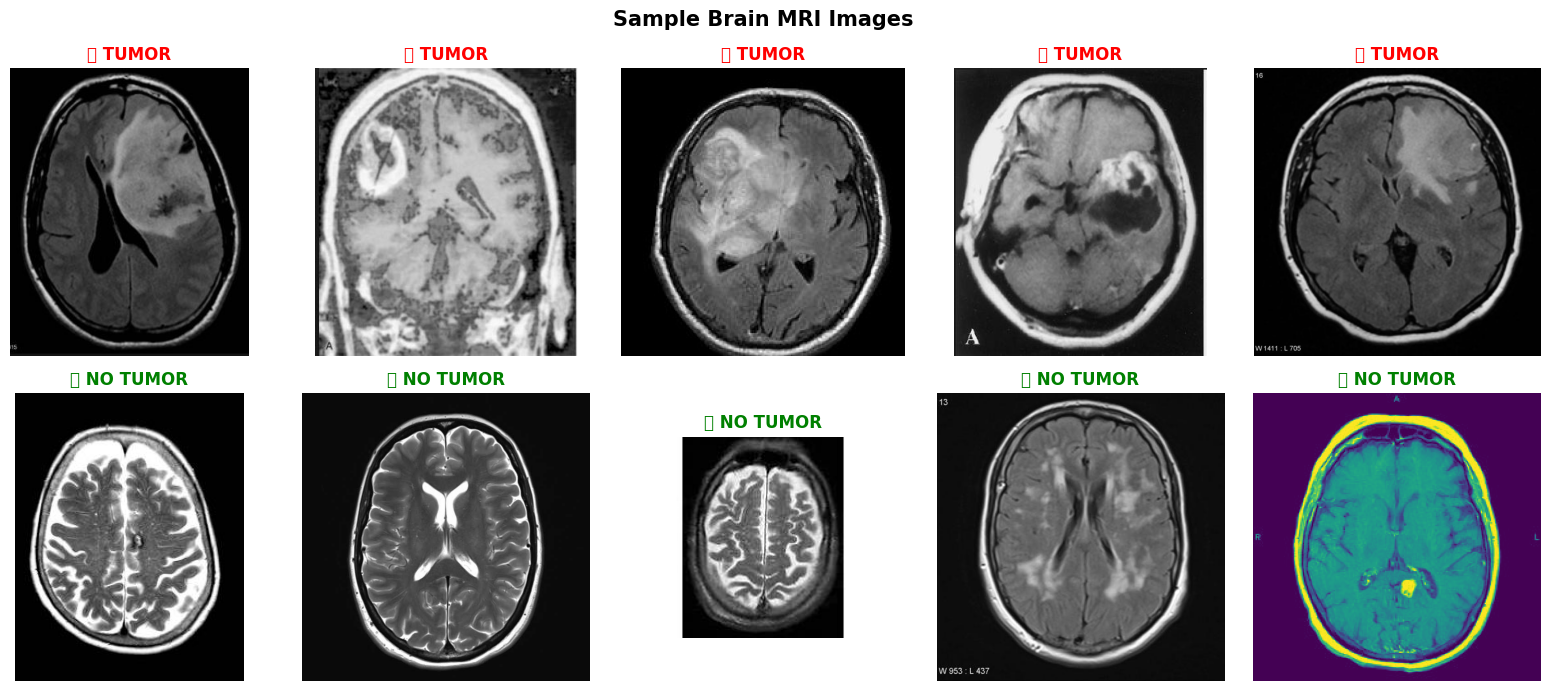

In [16]:
# ── Show 5 tumor + 5 no-tumor sample images ──
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Brain MRI Images', fontsize=15, fontweight='bold')

for i in range(5):
    img = mpimg.imread(os.path.join(YES_DIR, yes_imgs[i]))
    axes[0, i].imshow(img)
    axes[0, i].set_title('TUMOR', color='red', fontweight='bold')
    axes[0, i].axis('off')

for i in range(5):
    img = mpimg.imread(os.path.join(NO_DIR, no_imgs[i]))
    axes[1, i].imshow(img)
    axes[1, i].set_title(' NO TUMOR', color='green', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()




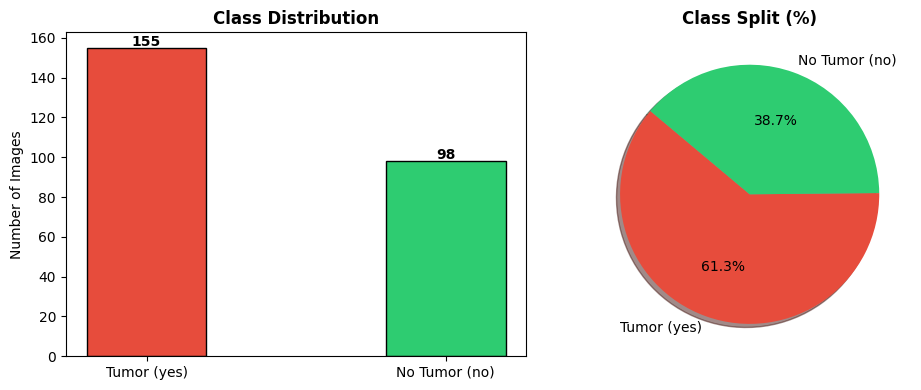

 Visualization done!


In [17]:
# ── Class distribution chart ──

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Tumor (yes)', 'No Tumor (no)']
counts = [len(yes_imgs), len(no_imgs)]
colors = ['#e74c3c', '#2ecc71']

axes2[0].bar(labels, counts, color=colors, edgecolor='black', width=0.4)
axes2[0].set_title('Class Distribution', fontweight='bold')
axes2[0].set_ylabel('Number of Images')
for i, v in enumerate(counts):
    axes2[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes2[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, shadow=True)
axes2[1].set_title('Class Split (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Visualization done!')

---
##  Step 4: Split into Train / Val / Test

In [18]:
SPLIT_DIR = '/content/split_data'

# Create train/val/test folder structure
for split in ['train', 'val', 'test']:
    for cls in ['yes', 'no']:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

def copy_split(img_list, src_dir, cls_name):
    """Split 70% train, 15% val, 15% test and copy files."""
    train_imgs, temp      = train_test_split(img_list, test_size=0.30, random_state=42)
    val_imgs,   test_imgs = train_test_split(temp,     test_size=0.50, random_state=42)
    for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        for f in imgs:
            shutil.copy(
                os.path.join(src_dir, f),
                os.path.join(SPLIT_DIR, split, cls_name, f)
            )
    return len(train_imgs), len(val_imgs), len(test_imgs)

y_tr, y_v, y_te = copy_split(yes_imgs, YES_DIR, 'yes')
n_tr, n_v, n_te = copy_split(no_imgs,  NO_DIR,  'no')

print('Split Complete!')
print(f'   Train → Tumor: {y_tr}  | No Tumor: {n_tr}  | Total: {y_tr+n_tr}')
print(f'   Val   → Tumor: {y_v}   | No Tumor: {n_v}   | Total: {y_v+n_v}')
print(f'   Test  → Tumor: {y_te}  | No Tumor: {n_te}  | Total: {y_te+n_te}')

 Split Complete!
   Train → Tumor: 108  | No Tumor: 68  | Total: 176
   Val   → Tumor: 23   | No Tumor: 15   | Total: 38
   Test  → Tumor: 24  | No Tumor: 15  | Total: 39


---
## 🔧 Step 5: Preprocessing & Augmentation

In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 16

# Augmentation only for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
print(f' Generators ready!')
print(f'   Class mapping: {train_gen.class_indices}')
print('   0 = no (No Tumor)  |  1 = yes (Tumor)')

Found 176 images belonging to 2 classes.
Found 38 images belonging to 2 classes.
Found 39 images belonging to 2 classes.
 Generators ready!
   Class mapping: {'no': 0, 'yes': 1}
   0 = no (No Tumor)  |  1 = yes (Tumor)


---
##  Step 6: Build Custom CNN

In [7]:
def build_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.40),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.50),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,769 (98.36 MB)

 Trainable params: 25,784,321 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

---
##  Step 7: Build VGG16 Transfer Learning Model

In [8]:
def build_vgg16():
    base = VGG16(weights='imagenet',
                 include_top=False,
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False  # Freeze all VGG16 layers

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.5)(x)
    x       = layers.Dense(64, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model, base

vgg_model, vgg_base = build_vgg16()
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,863,553 (56.70 MB)

 Trainable params: 148,353 (579.50 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

---
##  Step 8: Train Both Models

In [9]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{name}_best.keras',
                        monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

# Train Custom CNN
print('=' * 45)
print('   Training Custom CNN...')
print('=' * 45)
cnn_history = cnn_model.fit(
    train_gen, epochs=30,
    validation_data=val_gen,
    callbacks=get_callbacks('cnn'),
    verbose=1
)
print('\n Custom CNN training complete!')

   Training Custom CNN...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 561ms/step - accuracy: 0.6113 - loss: 22.2773 - val_accuracy: 0.8158 - val_loss: 1.0379 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.6148 - loss: 16.2839 - val_accuracy: 0.6316 - val_loss: 3.0318 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step - accuracy: 0.6271 - loss: 14.5714 - val_accuracy: 0.6842 - val_loss: 2.1059 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.7166 - loss: 13.2246 - val_accuracy: 0.6053 - val_loss: 5.7856 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.6822 - loss: 9.7228
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.6808 - loss: 9.7212 - val_accuracy: 0.5526 - val_loss: 9.0054 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accu

In [10]:
# Train VGG16 Phase 1 (frozen base)
print('=' * 45)
print('   Training VGG16 Phase 1...')
print('=' * 45)
vgg_h1 = vgg_model.fit(
    train_gen, epochs=20,
    validation_data=val_gen,
    callbacks=get_callbacks('vgg_p1'),
    verbose=1
)
print('\n VGG16 Phase 1 complete!')

   Training VGG16 Phase 1...
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 691ms/step - accuracy: 0.5699 - loss: 0.6883 - val_accuracy: 0.6053 - val_loss: 0.6294 - learning_rate: 0.0010
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.7457 - loss: 0.5292 - val_accuracy: 0.6053 - val_loss: 0.6072 - learning_rate: 0.0010
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 0.7447 - loss: 0.5200 - val_accuracy: 0.6053 - val_loss: 0.6015 - learning_rate: 0.0010
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.8620 - loss: 0.3134 - val_accuracy: 0.6053 - val_loss: 0.5872 - learning_rate: 0.0010
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.8765 - loss: 0.3488 - val_accuracy: 0.6316 - val_loss: 0.5742 - learning_rate: 0.0010
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.9179 - loss: 0.2532 - val_accuracy: 0.6842 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accu

In [19]:
# VGG16 Phase 2 — Fine-tune last 4 layers
print('=' * 45)
print('   VGG16 Phase 2 — Fine-tuning...')
print('=' * 45)

vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False

# Use much lower learning rate for fine-tuning
vgg_model.compile(optimizer=Adam(1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

vgg_h2 = vgg_model.fit(
    train_gen, epochs=15,
    validation_data=val_gen,
    callbacks=get_callbacks('vgg_p2'),
    verbose=1
)
print('\n Fine-tuning complete!')

   VGG16 Phase 2 — Fine-tuning...
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 425ms/step - accuracy: 0.9044 - loss: 0.1860 - val_accuracy: 0.8158 - val_loss: 0.5224 - learning_rate: 1.0000e-05
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step - accuracy: 0.9090 - loss: 0.1822 - val_accuracy: 0.7895 - val_loss: 0.5566 - learning_rate: 1.0000e-05
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.9425 - loss: 0.1406 - val_accuracy: 0.8158 - val_loss: 0.5412 - learning_rate: 1.0000e-05
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step - accuracy: 0.9521 - loss: 0.1331 - val_accuracy: 0.8421 - val_loss: 0.5090 - learning_rate: 1.0000e-05
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - accuracy: 0.9581 - loss: 0.1066 - val_accuracy: 0.8158 - val_loss: 0.4864 - learning_rate: 1.0000e-05
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - accuracy: 0.9519 - loss: 0.1038 - val_accuracy: 0.8421 - val_loss: 0.4884 - learning_rate: 1.0000e-05
Epoch 7/15
11/11 ━━━━━━━━━━━━

---
##  Step 9: Plot Training Curves

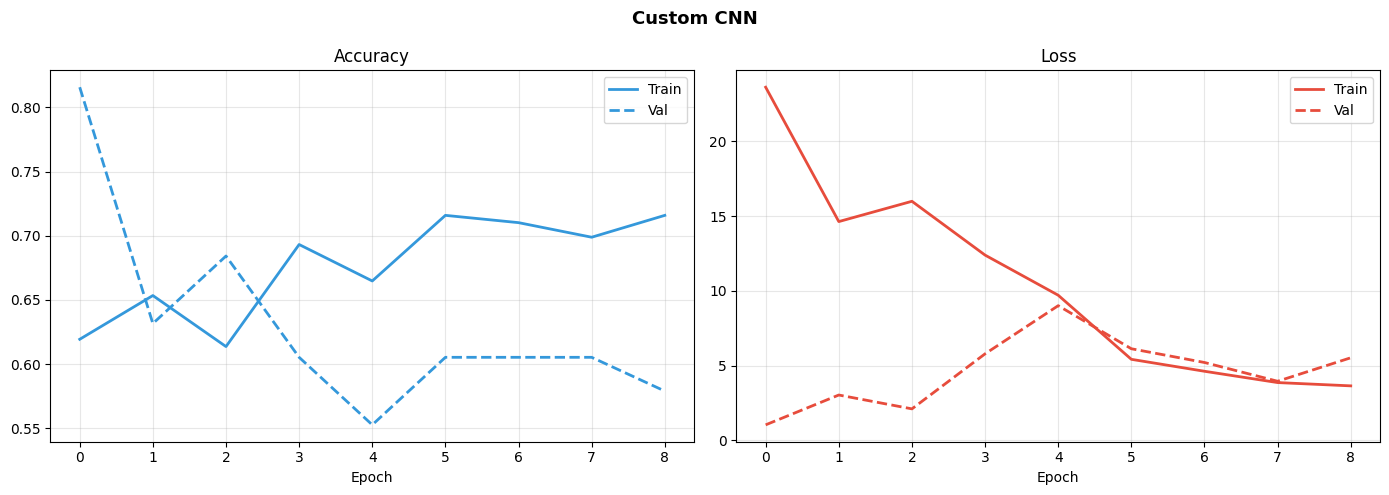

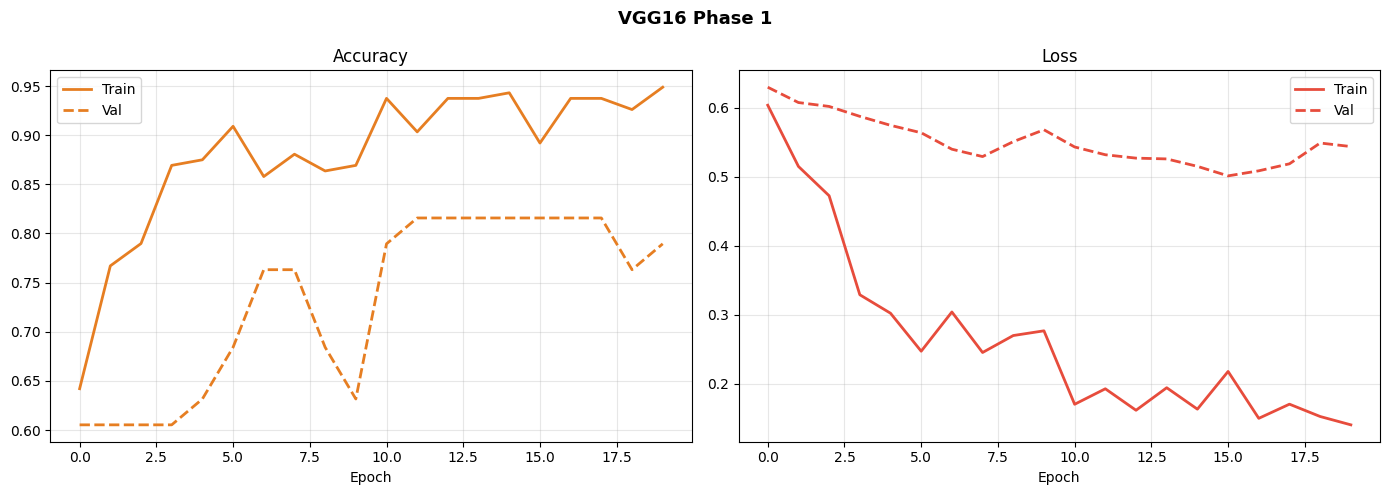

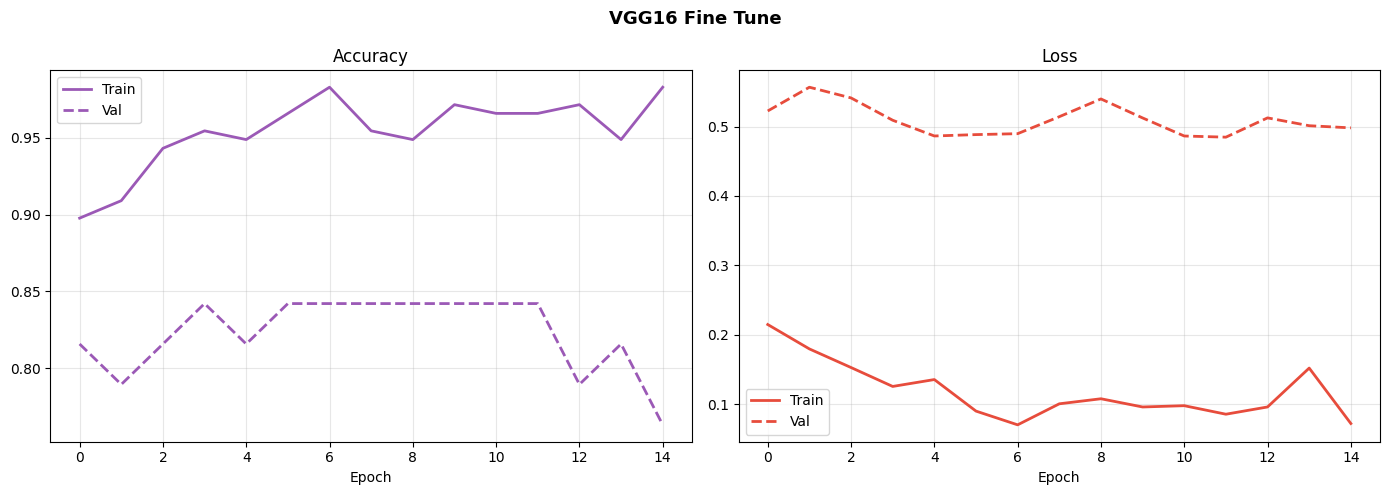

In [20]:
def plot_history(history, title, color='#3498db'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train', color=color, lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   color=color, lw=2, ls='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', color='#e74c3c', lw=2)
    axes[1].plot(history.history['val_loss'], label='Val',   color='#e74c3c', lw=2, ls='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(cnn_history, 'Custom CNN',        '#3498db')
plot_history(vgg_h1,      'VGG16 Phase 1',     '#e67e22')
plot_history(vgg_h2,      'VGG16 Fine Tune',   '#9b59b6')

---
##  Step 10: Evaluate — Accuracy, Confusion Matrix, Report


   Evaluating: Custom CNN

  Test Accuracy : 76.92%

  Classification Report:
              precision    recall  f1-score   support

          no       0.80      0.53      0.64        15
         yes       0.76      0.92      0.83        24

    accuracy                           0.77        39
   macro avg       0.78      0.72      0.74        39
weighted avg       0.77      0.77      0.76        39



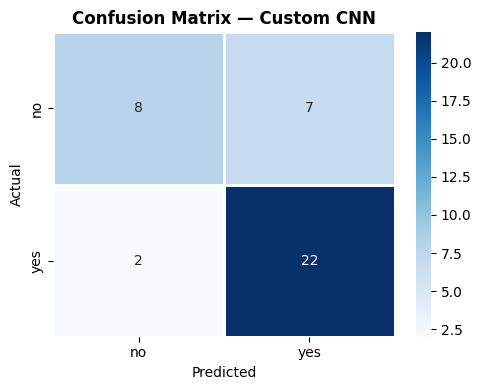


   Evaluating: VGG16 Transfer Learning

  Test Accuracy : 84.62%

  Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.67      0.77        15
         yes       0.82      0.96      0.88        24

    accuracy                           0.85        39
   macro avg       0.87      0.81      0.83        39
weighted avg       0.86      0.85      0.84        39



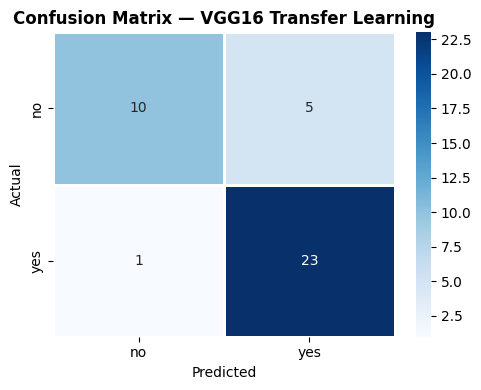

In [21]:
def evaluate_model(model, generator, model_name):
    print(f'\n{"="*50}')
    print(f'  Evaluating: {model_name}')
    print(f'{"="*50}')

    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    names  = list(generator.class_indices.keys())

    acc = accuracy_score(y_true, y_pred)
    print(f'\n  Test Accuracy : {acc*100:.2f}%')
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, linewidths=1)
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()
    return acc

cnn_acc = evaluate_model(cnn_model, test_gen, 'Custom CNN')
vgg_acc = evaluate_model(vgg_model, test_gen, 'VGG16 Transfer Learning')

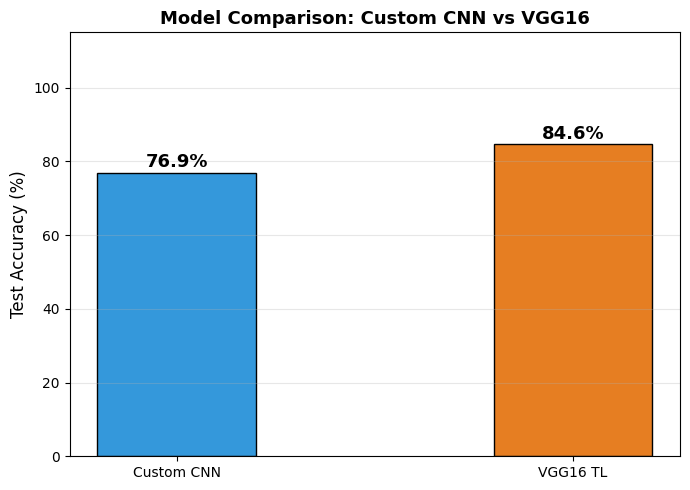


 Best Model: VGG16 TL with 84.62% accuracy


In [22]:
# ── Model Comparison Bar Chart ──
plt.figure(figsize=(7, 5))
bars = plt.bar(['Custom CNN', 'VGG16 TL'],
               [cnn_acc*100, vgg_acc*100],
               color=['#3498db', '#e67e22'],
               edgecolor='black', width=0.4)
plt.ylim([0, 115])
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Comparison: Custom CNN vs VGG16', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, [cnn_acc*100, vgg_acc*100]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{acc:.1f}%', ha='center', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

winner = 'VGG16 TL' if vgg_acc > cnn_acc else 'Custom CNN'
print(f'\n Best Model: {winner} with {max(cnn_acc, vgg_acc)*100:.2f}% accuracy')

---
## 🔬 Step 11: Predict on a Single Image

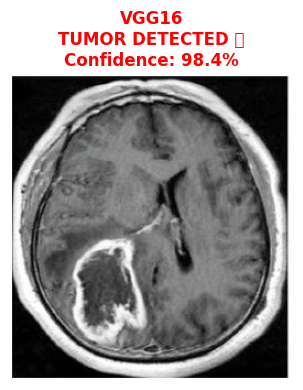

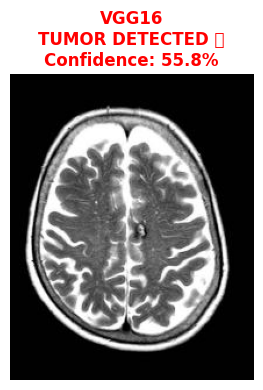

In [23]:
def predict_image(model, img_path, model_name='VGG16'):
    img   = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr   = img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    prob  = model.predict(arr, verbose=0)[0][0]
    label = 'TUMOR DETECTED ' if prob > 0.5 else 'NO TUMOR 🟢'
    conf  = prob if prob > 0.5 else 1 - prob
    color = 'red' if prob > 0.5 else 'green'

    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(img_path))
    plt.title(f'{model_name}\n{label}\nConfidence: {conf*100:.1f}%',
              fontsize=12, fontweight='bold', color=color)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Test on one tumor and one no-tumor image from the test set
tumor_sample    = os.path.join(SPLIT_DIR, 'test', 'yes',
                    os.listdir(os.path.join(SPLIT_DIR,'test','yes'))[0])
no_tumor_sample = os.path.join(SPLIT_DIR, 'test', 'no',
                    os.listdir(os.path.join(SPLIT_DIR,'test','no'))[0])

predict_image(vgg_model, tumor_sample,    'VGG16')
predict_image(vgg_model, no_tumor_sample, 'VGG16')

In [ ]:
# ── Upload ANY MRI image and test it ──
from google.colab import files
print('📤 Upload your own MRI image to test:')
my_upload = files.upload()

for fname in my_upload.keys():
    predict_image(vgg_model, fname, 'VGG16')

In [25]:
vgg_model.save('brain_tumor_vgg16.keras')
cnn_model.save('brain_tumor_cnn.keras')
print(' Models saved!')

# Download best model to your PC
from google.colab import files
files.download('brain_tumor_vgg16.keras')

 Models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>